# 09 — Model Explainability

## EduPredict — Explain Why the Model Predicts a Student's Exam Score

This notebook explains the final trained model from Notebook 08.

### Goals
- Load the saved final model.
- Identify which original input features contribute most to predictions.
- Use permutation importance on the held-out test data.
- Produce global feature-importance visualizations.
- Generate local explanations for individual students using prediction perturbation.
- Save explainability artifacts for the final report and Streamlit dashboard.

> **Important:** Explainability shows model behavior. It does not prove that a feature causes a student's score to change.


In [1]:
# 1. Imports and configuration

from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = Path("../data/processed/student_performance_engineered.csv")
MODEL_PATH = Path("../models/edupredict_final_pipeline.joblib")
SELECTION_PATH = Path("../outputs/metrics/selected_features.json")

METRICS_DIR = Path("../outputs/metrics")
EXPLAIN_DIR = Path("../outputs/explainability")

METRICS_DIR.mkdir(parents=True, exist_ok=True)
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")


Configuration loaded.


In [2]:
# 2. Load dataset and final model

df = pd.read_csv(DATA_PATH)

assert MODEL_PATH.exists(), (
    f"Final model not found: {MODEL_PATH}. "
    "Run Notebook 08 first."
)

final_pipeline = joblib.load(MODEL_PATH)

print("Dataset shape:", df.shape)
print("Final model loaded:", MODEL_PATH)
print("Pipeline steps:", list(final_pipeline.named_steps.keys()))


Dataset shape: (6606, 22)
Final model loaded: ../models/edupredict_final_pipeline.joblib
Pipeline steps: ['preprocessor', 'model']


In [3]:
# 3. Recover the exact feature set

candidate_features = [
    c for c in df.columns
    if c != "Exam_Score"
]

if SELECTION_PATH.exists():
    with open(SELECTION_PATH, "r") as f:
        selection_info = json.load(f)

    selected_features = [
        c for c in selection_info.get("selected_features", [])
        if c in candidate_features
    ]
else:
    selected_features = []

feature_columns = (
    selected_features
    if selected_features
    else candidate_features
)

X = df[feature_columns].copy()
y = df["Exam_Score"].copy()

print("Number of features:", len(feature_columns))
print(feature_columns)


Number of features: 21
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Study_Attendance_Interaction', 'Study_Sleep_Interaction']


In [4]:
# 4. Recreate the exact test set used in Notebook 08

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Test set shape:", X_test.shape)
print("Test target shape:", y_test.shape)


Test set shape: (1322, 21)
Test target shape: (1322,)


In [5]:
# 5. Verify the saved model on the test set

test_predictions = final_pipeline.predict(X_test)

test_rmse = mean_squared_error(
    y_test,
    test_predictions
) ** 0.5

print(f"Test RMSE: {test_rmse:.4f}")


Test RMSE: 1.5224


## Global Explainability — Permutation Importance

Permutation importance measures how much the model's predictive performance changes when one input feature is randomly shuffled.

If shuffling a feature makes performance substantially worse, that feature was important to the model for the evaluated data.

This method works at the **original feature level**, so it is easier to communicate than raw one-hot encoded coefficient/importance names.


In [6]:
# 6. Calculate permutation importance

perm = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

importance_df["absolute_importance"] = (
    importance_df["importance_mean"].abs()
)

importance_df = (
    importance_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(20))


,feature,importance_mean,importance_std,absolute_importance
0,Attendance,1.835971,0.034134,1.835971
1,Hours_Studied,0.825860,0.015505,0.825860
2,Access_to_Resources,0.296887,0.014845,0.296887
3,Previous_Scores,0.296830,0.014321,0.296830
4,Parental_Involvement,0.288611,0.010296,0.288611
5,Tutoring_Sessions,0.221184,0.011394,0.221184
6,Study_Attendance_Interaction,0.126761,0.005096,0.126761
7,Family_Income,0.108867,0.009653,0.108867
8,Peer_Influence,0.100119,0.005045,0.100119
9,Parental_Education_Level,0.088870,0.009996,0.088870


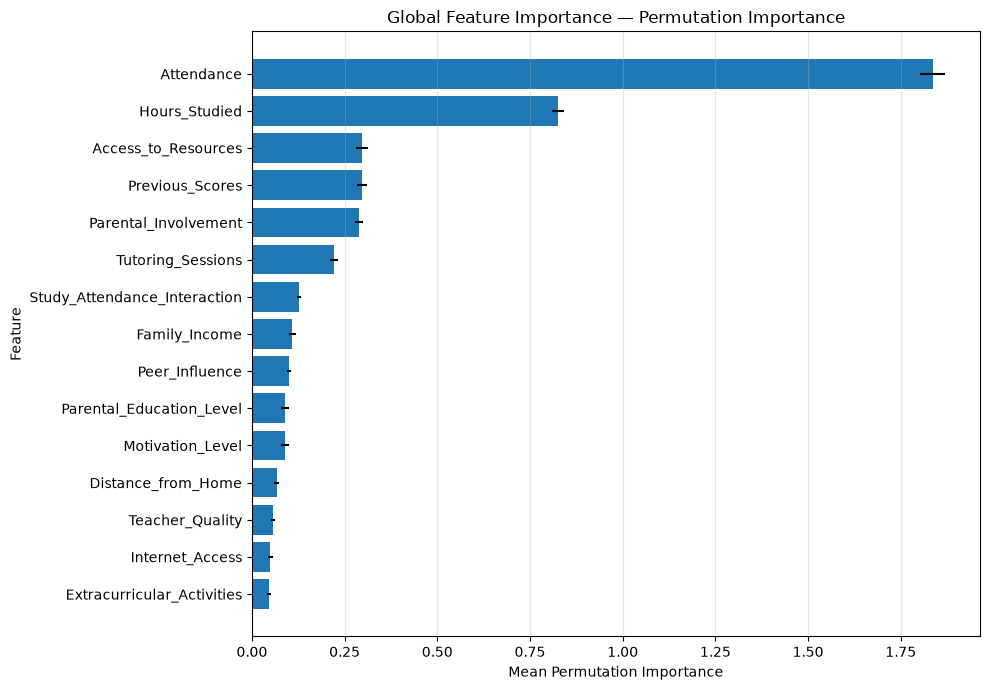

In [7]:
# 7. Plot global permutation importance

plot_df = (
    importance_df
    .sort_values("importance_mean", ascending=True)
    .tail(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

plt.xlabel("Mean Permutation Importance")
plt.ylabel("Feature")
plt.title("Global Feature Importance — Permutation Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
# 8. Save global explainability results

importance_df.to_csv(
    EXPLAIN_DIR / "permutation_importance.csv",
    index=False
)

print("Saved:")
print(EXPLAIN_DIR / "permutation_importance.csv")


Saved:
../outputs/explainability/permutation_importance.csv


## Local Explainability

For a single student, we can inspect how changing one input feature affects the model's prediction while keeping the other inputs fixed.

This is a **model sensitivity analysis**, not a causal explanation.


In [9]:
# 9. Select one real test-set student

student_position = 0

student = X_test.iloc[[student_position]].copy()
actual_score = float(y_test.iloc[student_position])
base_prediction = float(final_pipeline.predict(student)[0])

print("Selected test student:")
display(student)

print(f"Actual score:     {actual_score:.2f}")
print(f"Predicted score:  {base_prediction:.2f}")
print(f"Prediction error: {actual_score - base_prediction:.2f}")


Selected test student:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Study_Attendance_Interaction,Study_Sleep_Interaction
6414,16,82,Medium,Medium,No,6,91,Medium,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Female,1312,96


Actual score:     66.00
Predicted score:  66.02
Prediction error: -0.02


In [10]:
# 10. Local one-feature perturbation analysis

local_results = []

for feature in feature_columns:

    original_value = student.iloc[0][feature]

    if pd.api.types.is_numeric_dtype(X_test[feature]):
        feature_median = X_train[feature].median()

        modified = student.copy()
        modified[feature] = feature_median

        modified_prediction = float(
            final_pipeline.predict(modified)[0]
        )

        prediction_change = (
            modified_prediction - base_prediction
        )

        local_results.append({
            "feature": feature,
            "original_value": original_value,
            "comparison_value": feature_median,
            "base_prediction": base_prediction,
            "modified_prediction": modified_prediction,
            "prediction_change": prediction_change
        })

    else:
        local_results.append({
            "feature": feature,
            "original_value": original_value,
            "comparison_value": "Not perturbed",
            "base_prediction": base_prediction,
            "modified_prediction": np.nan,
            "prediction_change": np.nan
        })

local_df = pd.DataFrame(local_results)

display(
    local_df
    .dropna(subset=["prediction_change"])
    .sort_values(
        "prediction_change",
        key=lambda s: s.abs(),
        ascending=False
    )
    .head(15)
)


,feature,original_value,comparison_value,base_prediction,modified_prediction,prediction_change
0,Hours_Studied,16,20.0,66.019652,66.839572,0.819919
6,Previous_Scores,91,75.0,66.019652,65.237221,-0.782431
9,Tutoring_Sessions,0,1.0,66.019652,66.501481,0.481829
1,Attendance,82,80.0,66.019652,65.655126,-0.364527
19,Study_Attendance_Interaction,1312,1566.0,66.019652,66.222210,0.202557
20,Study_Sleep_Interaction,96,136.0,66.019652,66.153881,0.134229
5,Sleep_Hours,6,7.0,66.019652,65.945375,-0.074277
14,Physical_Activity,3,3.0,66.019652,66.019652,0.000000


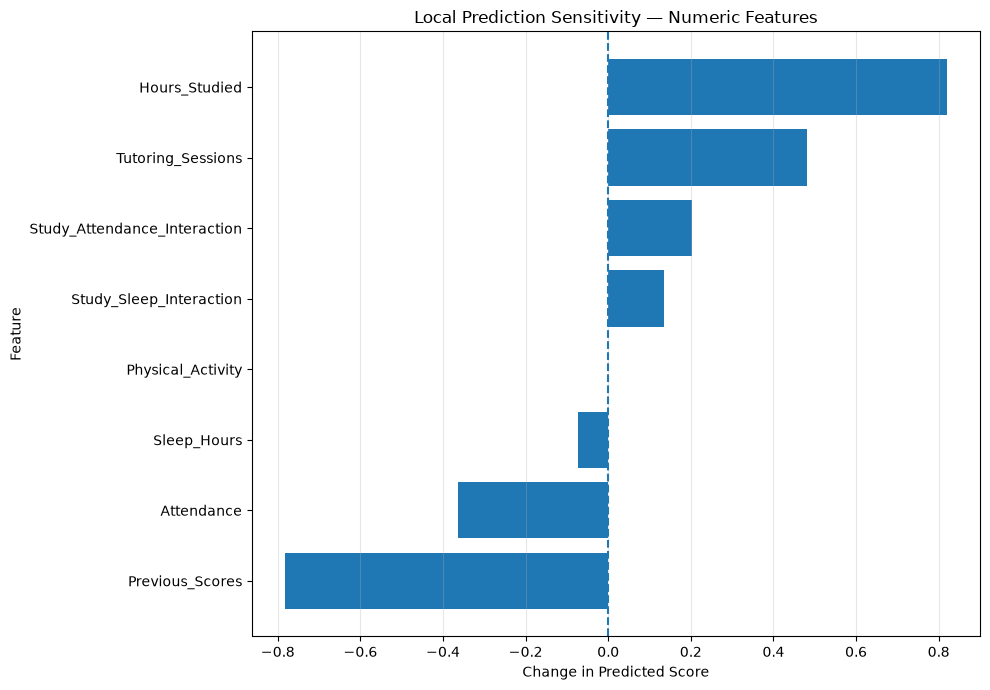

In [11]:
# 11. Plot local numeric sensitivity

local_numeric = (
    local_df
    .dropna(subset=["prediction_change"])
    .sort_values("prediction_change")
)

plt.figure(figsize=(10, 7))

plt.barh(
    local_numeric["feature"],
    local_numeric["prediction_change"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Change in Predicted Score")
plt.ylabel("Feature")
plt.title("Local Prediction Sensitivity — Numeric Features")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# 12. Save local explanation

local_df.to_csv(
    EXPLAIN_DIR / "local_prediction_explanation.csv",
    index=False
)

local_summary = {
    "test_student_position": int(student_position),
    "actual_score": actual_score,
    "base_prediction": base_prediction,
    "prediction_error": actual_score - base_prediction
}

with open(
    EXPLAIN_DIR / "local_explanation_summary.json",
    "w"
) as f:
    json.dump(local_summary, f, indent=4)

print("Saved local explanation artifacts.")


Saved local explanation artifacts.


## Optional SHAP Extension

SHAP can provide richer local and global explanations, but it introduces another dependency and may require model-specific handling for tree ensembles and pipelines.

For the core project, permutation importance plus local sensitivity analysis is kept as the reproducible baseline explainability approach.

If SHAP is installed and the final estimator is a supported tree model, it can be added as an optional extension rather than making the core notebook depend on it.


In [13]:
# 13. Final explainability summary

top_features = (
    importance_df
    .head(10)["feature"]
    .tolist()
)

explainability_summary = {
    "test_rmse": float(test_rmse),
    "top_features": top_features,
    "global_method": "Permutation Importance",
    "local_method": "Numeric one-feature perturbation sensitivity",
    "warning": (
        "Feature importance and sensitivity describe model behavior "
        "and should not be interpreted as causal effects."
    )
}

with open(
    EXPLAIN_DIR / "explainability_summary.json",
    "w"
) as f:
    json.dump(explainability_summary, f, indent=4)

print("Top model features:")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

print("\nExplainability summary saved.")


Top model features:
1. Attendance
2. Hours_Studied
3. Access_to_Resources
4. Previous_Scores
5. Parental_Involvement
6. Tutoring_Sessions
7. Study_Attendance_Interaction
8. Family_Income
9. Peer_Influence
10. Parental_Education_Level

Explainability summary saved.


## Notebook 09 completion checklist

- [ ] Final model loaded from Notebook 08.
- [ ] Exact test set recreated.
- [ ] Test RMSE verified.
- [ ] Permutation importance calculated.
- [ ] Global feature importance plotted.
- [ ] Local student sensitivity analysis generated.
- [ ] Explainability artifacts saved.
- [ ] No causal claims made from feature importance.

### Saved artifacts

```text
outputs/explainability/
├── permutation_importance.csv
├── local_prediction_explanation.csv
├── local_explanation_summary.json
└── explainability_summary.json
```

**Next phase:** convert the validated notebook workflow into the production MLOps system — DVC, MLflow, FastAPI, Streamlit, Docker, and GitHub Actions.
